In [1]:
# System
import os
import sys

os.environ["KERAS_BACKEND"] = "jax"
sys.path.append("../..")

In [2]:
# Setup
from importlib import import_module
from pathlib import Path
from time import time
from typing import cast

import numpy as np
import pandas as pd
from keras import ops
from src.callbacks import ImportanceUpdate
from src.models import LearnableCutFlowModel, LearnableCutFlowSequentialModel
from src.utils import (
    load_model,
    plot_learned_cut,
    plot_learned_importance,
    print,
    tex_to_str,
)

In [3]:
# Parameters
n_runs = 10

# Dataset
dataset = "mock1"
n_samples = 200000
seed = 42

# Model
model_builder = "LearnableCutFlowParallel"  # *
centers = [-2, 2, 0, 0]  # *
n_epochs = 200
batch_size = 512

# Figure
features = [r"$x_1$", r"$x_2$", r"$x_3$", r"$x_4$"]
bins = np.linspace(-10, 10, 101)

# Directory
FIGURES_DIR = Path("figures")
CHECKPOINTS_DIR = Path("checkpoints")

FIGURES_DIR.mkdir(exist_ok=True)
CHECKPOINTS_DIR.mkdir(exist_ok=True)

In [4]:
# Dataset
module = import_module(f"src.datasets.{dataset}")
load_data = getattr(module, "load_data")
(x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

x_train.shape=(100000, 4)
y_train.shape=(100000, 1)
x_test.shape=(100000, 4)
y_test.shape=(100000, 1)


In [5]:
# Model
training_time = []

for i in range(n_runs):
    print(f"Training model {i + 1} of {n_runs}")

    ModelBuilder = getattr(import_module("src.models"), model_builder)
    model = ModelBuilder(x_train.shape, centers, features=features, name="lcf_par")
    model = cast(LearnableCutFlowModel, model)

    model.adapt(x_train)
    model.compile(optimizer="adam", loss="crossentropy")

    start_time = time()
    model.fit(
        x_train,
        y_train,
        epochs=n_epochs,
        batch_size=batch_size,
        callbacks=[ImportanceUpdate(model)],
        verbose=2,
    )
    training_time.append(time() - start_time)

    model.save(CHECKPOINTS_DIR / f"model@{i + 1}.keras")

training_time_mean = np.mean(training_time)
training_time_std = np.std(training_time)

print(f"\n\nTraining time: {training_time_mean:.2f} ± {training_time_std:.2f} seconds")

Training model 1 of 10
Epoch 1/200
196/196 - 4s - 20ms/step - loss: 0.3767
Epoch 2/200
196/196 - 1s - 6ms/step - loss: 0.3526
Epoch 3/200
196/196 - 0s - 770us/step - loss: 0.3339
Epoch 4/200
196/196 - 0s - 939us/step - loss: 0.3192
Epoch 5/200
196/196 - 0s - 808us/step - loss: 0.3074
Epoch 6/200
196/196 - 0s - 1ms/step - loss: 0.2977
Epoch 7/200
196/196 - 0s - 874us/step - loss: 0.2897
Epoch 8/200
196/196 - 0s - 887us/step - loss: 0.2832
Epoch 9/200
196/196 - 0s - 766us/step - loss: 0.2780
Epoch 10/200
196/196 - 0s - 868us/step - loss: 0.2734
Epoch 11/200
196/196 - 0s - 1ms/step - loss: 0.2691
Epoch 12/200
196/196 - 0s - 953us/step - loss: 0.2649
Epoch 13/200
196/196 - 0s - 856us/step - loss: 0.2606
Epoch 14/200
196/196 - 0s - 883us/step - loss: 0.2563
Epoch 15/200
196/196 - 0s - 1ms/step - loss: 0.2521
Epoch 16/200
196/196 - 0s - 1ms/step - loss: 0.2481
Epoch 17/200
196/196 - 0s - 1ms/step - loss: 0.2444
Epoch 18/200
196/196 - 0s - 883us/step - loss: 0.2411
Epoch 19/200
196/196 - 0s -

In [6]:
# Checkpoint
checkpoints = [
    load_model(CHECKPOINTS_DIR / f"model@{i + 1}.keras") for i in range(n_runs)
]
checkpoints = [cast(LearnableCutFlowModel, i) for i in checkpoints]

In [7]:
# Analysis: metrics (x10)
tp_list = []
fp_list = []
accuracy_list = []
precision_list = []
significance_list = []

for checkpoint in checkpoints:
    y_pred = checkpoint.predict(x_test, batch_size=batch_size, verbose=0)
    y_true = y_test

    tp = ops.sum((y_true == 1) & (y_pred == 1))
    fp = ops.sum((y_true == 0) & (y_pred == 1))
    tn = ops.sum((y_true == 0) & (y_pred == 0))
    fn = ops.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn)  # type: ignore
    precision = tp / (tp + fp)  # type: ignore
    significance = tp / ops.sqrt(fp)  # type: ignore

    tp_list.append(tp)
    fp_list.append(fp)
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    significance_list.append(significance)

tp_mean = ops.mean(tp_list)
tp_std = ops.std(tp_list)
fp_mean = ops.mean(fp_list)
fp_std = ops.std(fp_list)
accuracy_mean = ops.mean(accuracy_list)
accuracy_std = ops.std(accuracy_list)
precision_mean = ops.mean(precision_list)
precision_std = ops.std(precision_list)
significance_mean = ops.mean(significance_list)
significance_std = ops.std(significance_list)

print(f"True positives....{tp_mean:.2f} ± {tp_std:.2f}")
print(f"False positives...{fp_mean:.2f} ± {fp_std:.2f}")
print(f"Accuracy..........{accuracy_mean:.4f} ± {accuracy_std:.4f}")
print(f"Precision.........{precision_mean:.4f} ± {precision_std:.4f}")
print(f"Significance......{significance_mean:.4f} ± {significance_std:.4f}")

True positives....25756.10 ± 62.72
False positives...34.20 ± 0.40
Accuracy..........0.7586 ± 0.0006
Precision.........0.9987 ± 0.0000
Significance......4404.3999 ± 23.6516


In [8]:
# Analysis: learned cuts (x10)
cut_boundaries = []
cut_expressions = []
cut_cases = []
cut_indices = []

for i in range(x_test.shape[1]):
    case = checkpoints[0].cuts[i].case
    index = checkpoints[0].cuts[i].index
    boundaries = []

    for checkpoint in checkpoints:
        assert checkpoint.cuts[i].case == case
        assert checkpoint.cuts[i].index == index
        boundaries.append(checkpoint.cuts[i].boundaries)

    boundaries_mean = ops.mean(boundaries, axis=0)
    boundaries_std = ops.std(boundaries, axis=0)

    feature = checkpoints[0].cuts[i].feature
    if case == 1:
        print(f"{feature} < {boundaries_mean[index]:.4f} ± {boundaries_std[index]:.4f}")
        expression = f"{feature} < {boundaries_mean[index]:.4f}"
    elif case == 2:
        print(f"{feature} > {boundaries_mean[index]:.4f} ± {boundaries_std[index]:.4f}")
        expression = f"{feature} > {boundaries_mean[index]:.4f}"
    elif case == 3:
        print(
            f"{boundaries_mean[0]:.4f} ± {boundaries_std[0]:.4f} < {feature} "
            f"< {boundaries_mean[1]:.4f} ± {boundaries_std[1]:.4f}"
        )
        expression = f"{boundaries_mean[0]:.4f} < {feature} < {boundaries_mean[1]:.4f}"
    else:
        print(
            f"{feature} < {boundaries_mean[0]:.4f} ± {boundaries_std[0]:.4f} or "
            f"{feature} > {boundaries_mean[1]:.4f} ± {boundaries_std[1]:.4f}"
        )
        expression = (
            f"{feature} < {boundaries_mean[0]:.4f} or "
            f"{feature} > {boundaries_mean[1]:.4f}"
        )
    cut_boundaries.append(boundaries_mean)
    cut_expressions.append(expression)
    cut_cases.append(case)
    cut_indices.append(index)

$x_1$ < 0.0170 ± 0.0028
$x_2$ > -0.0049 ± 0.0032
-3.0514 ± 0.0077 < $x_3$ < 3.0349 ± 0.0081
$x_4$ < -3.0322 ± 0.0100 or $x_4$ > 3.0354 ± 0.0093


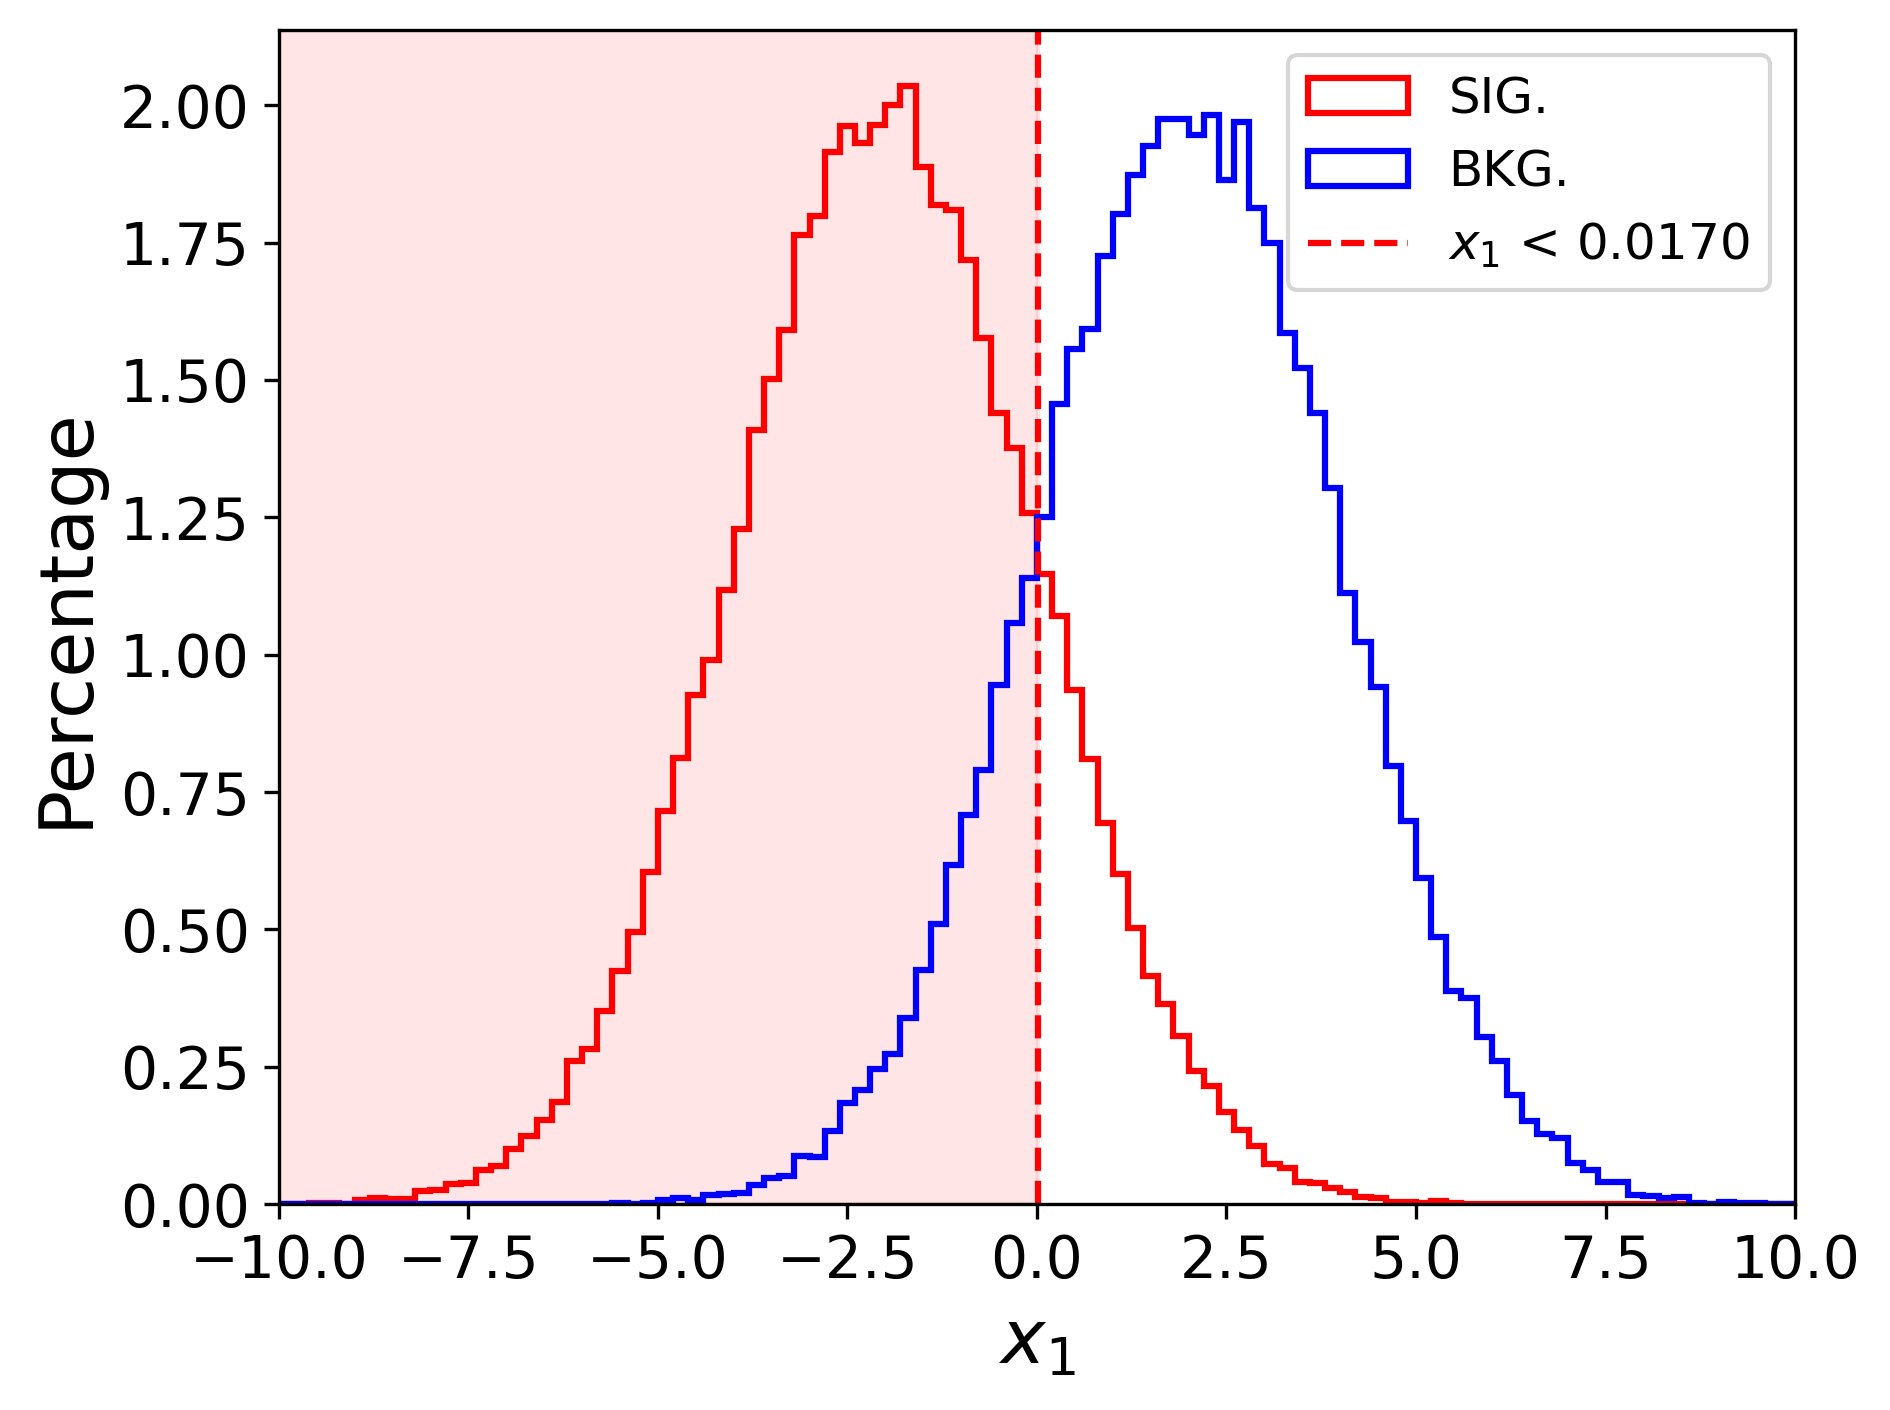

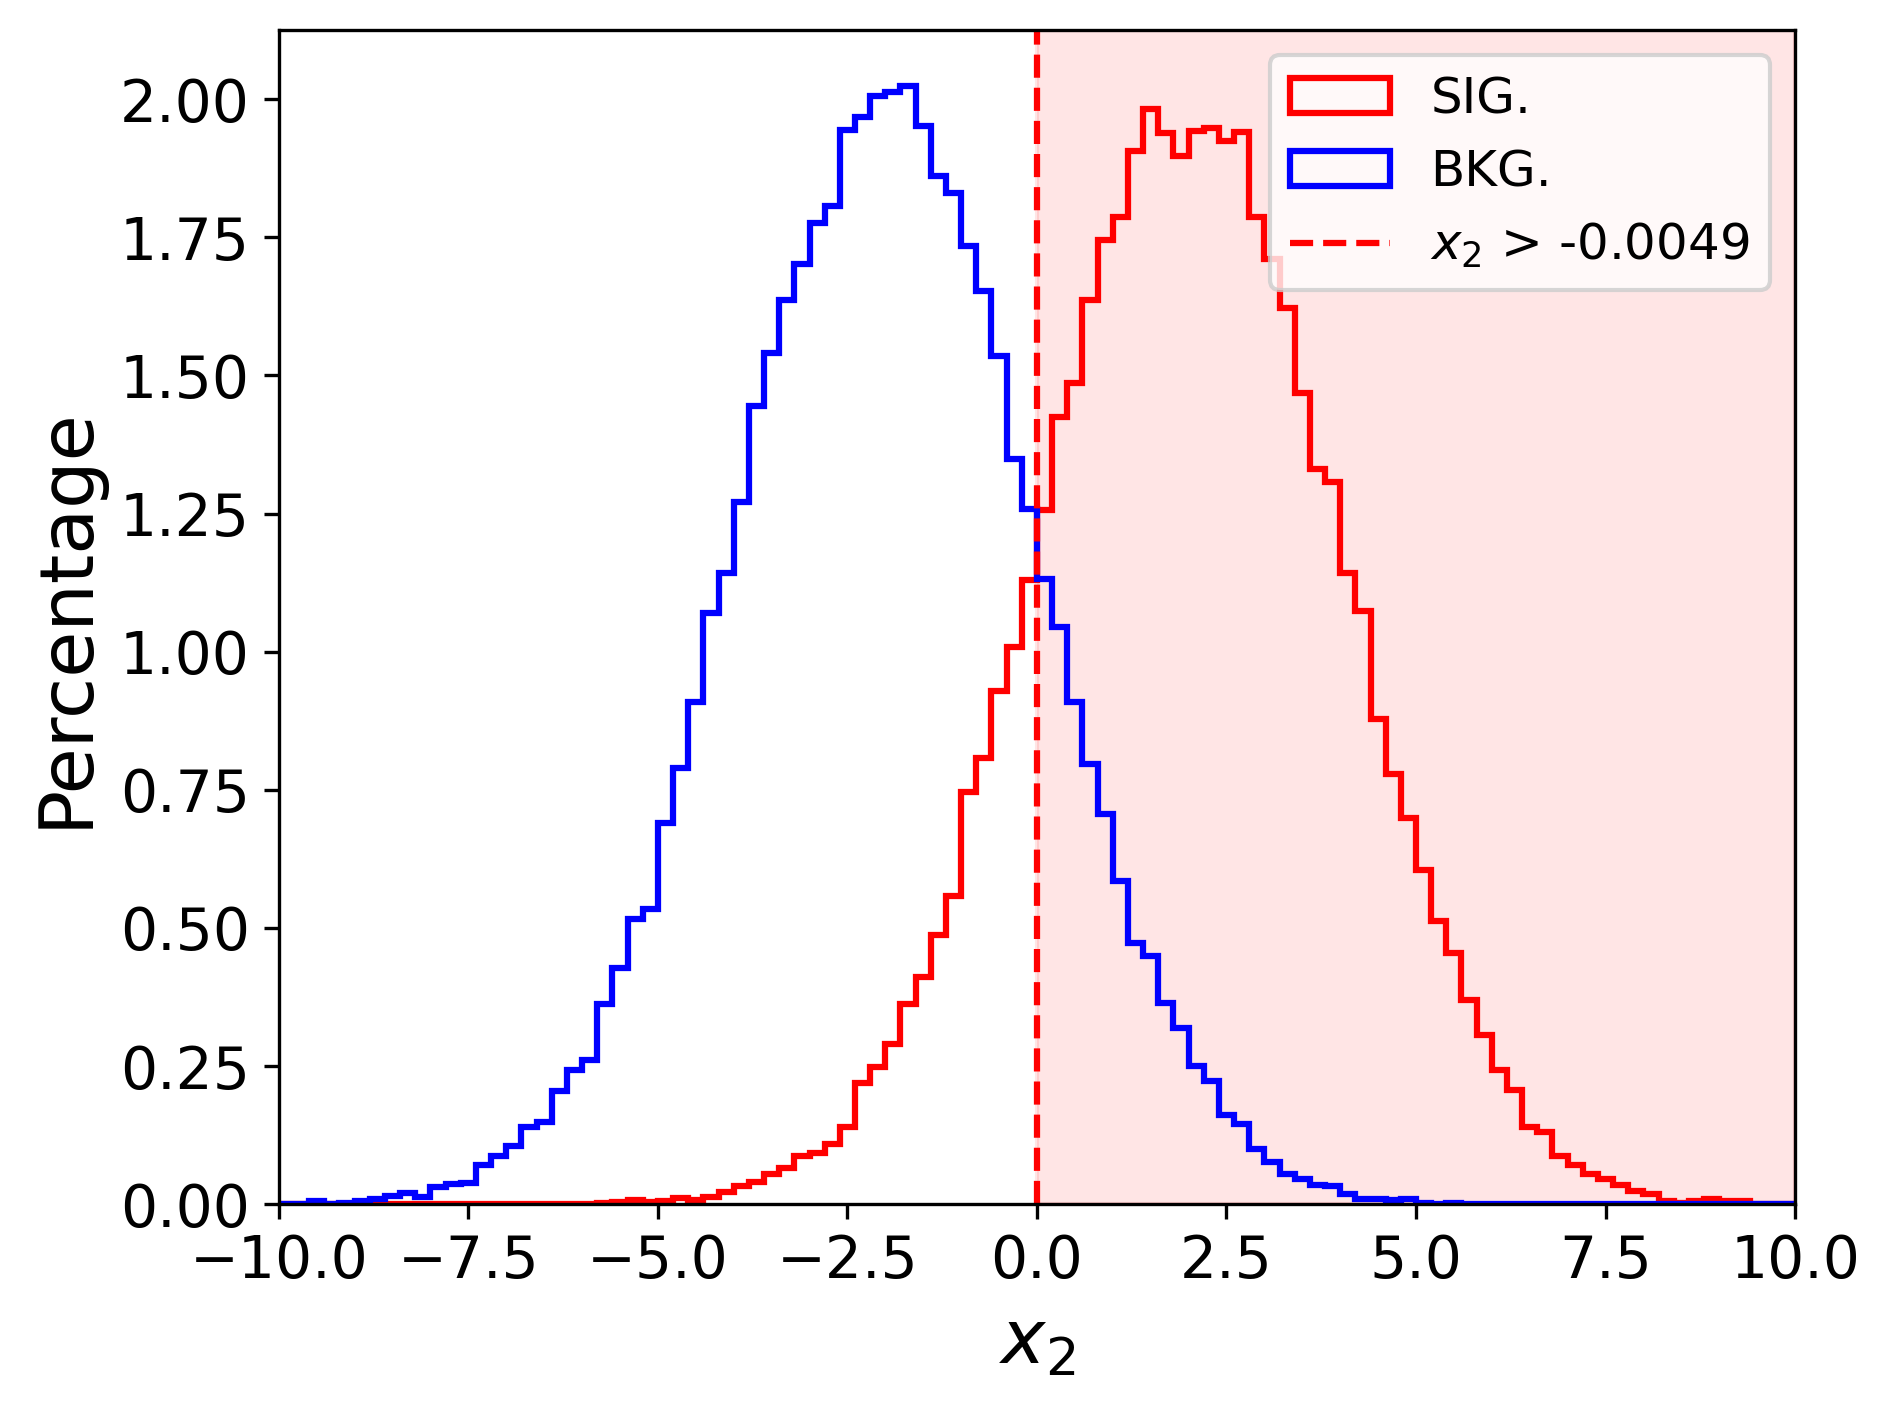

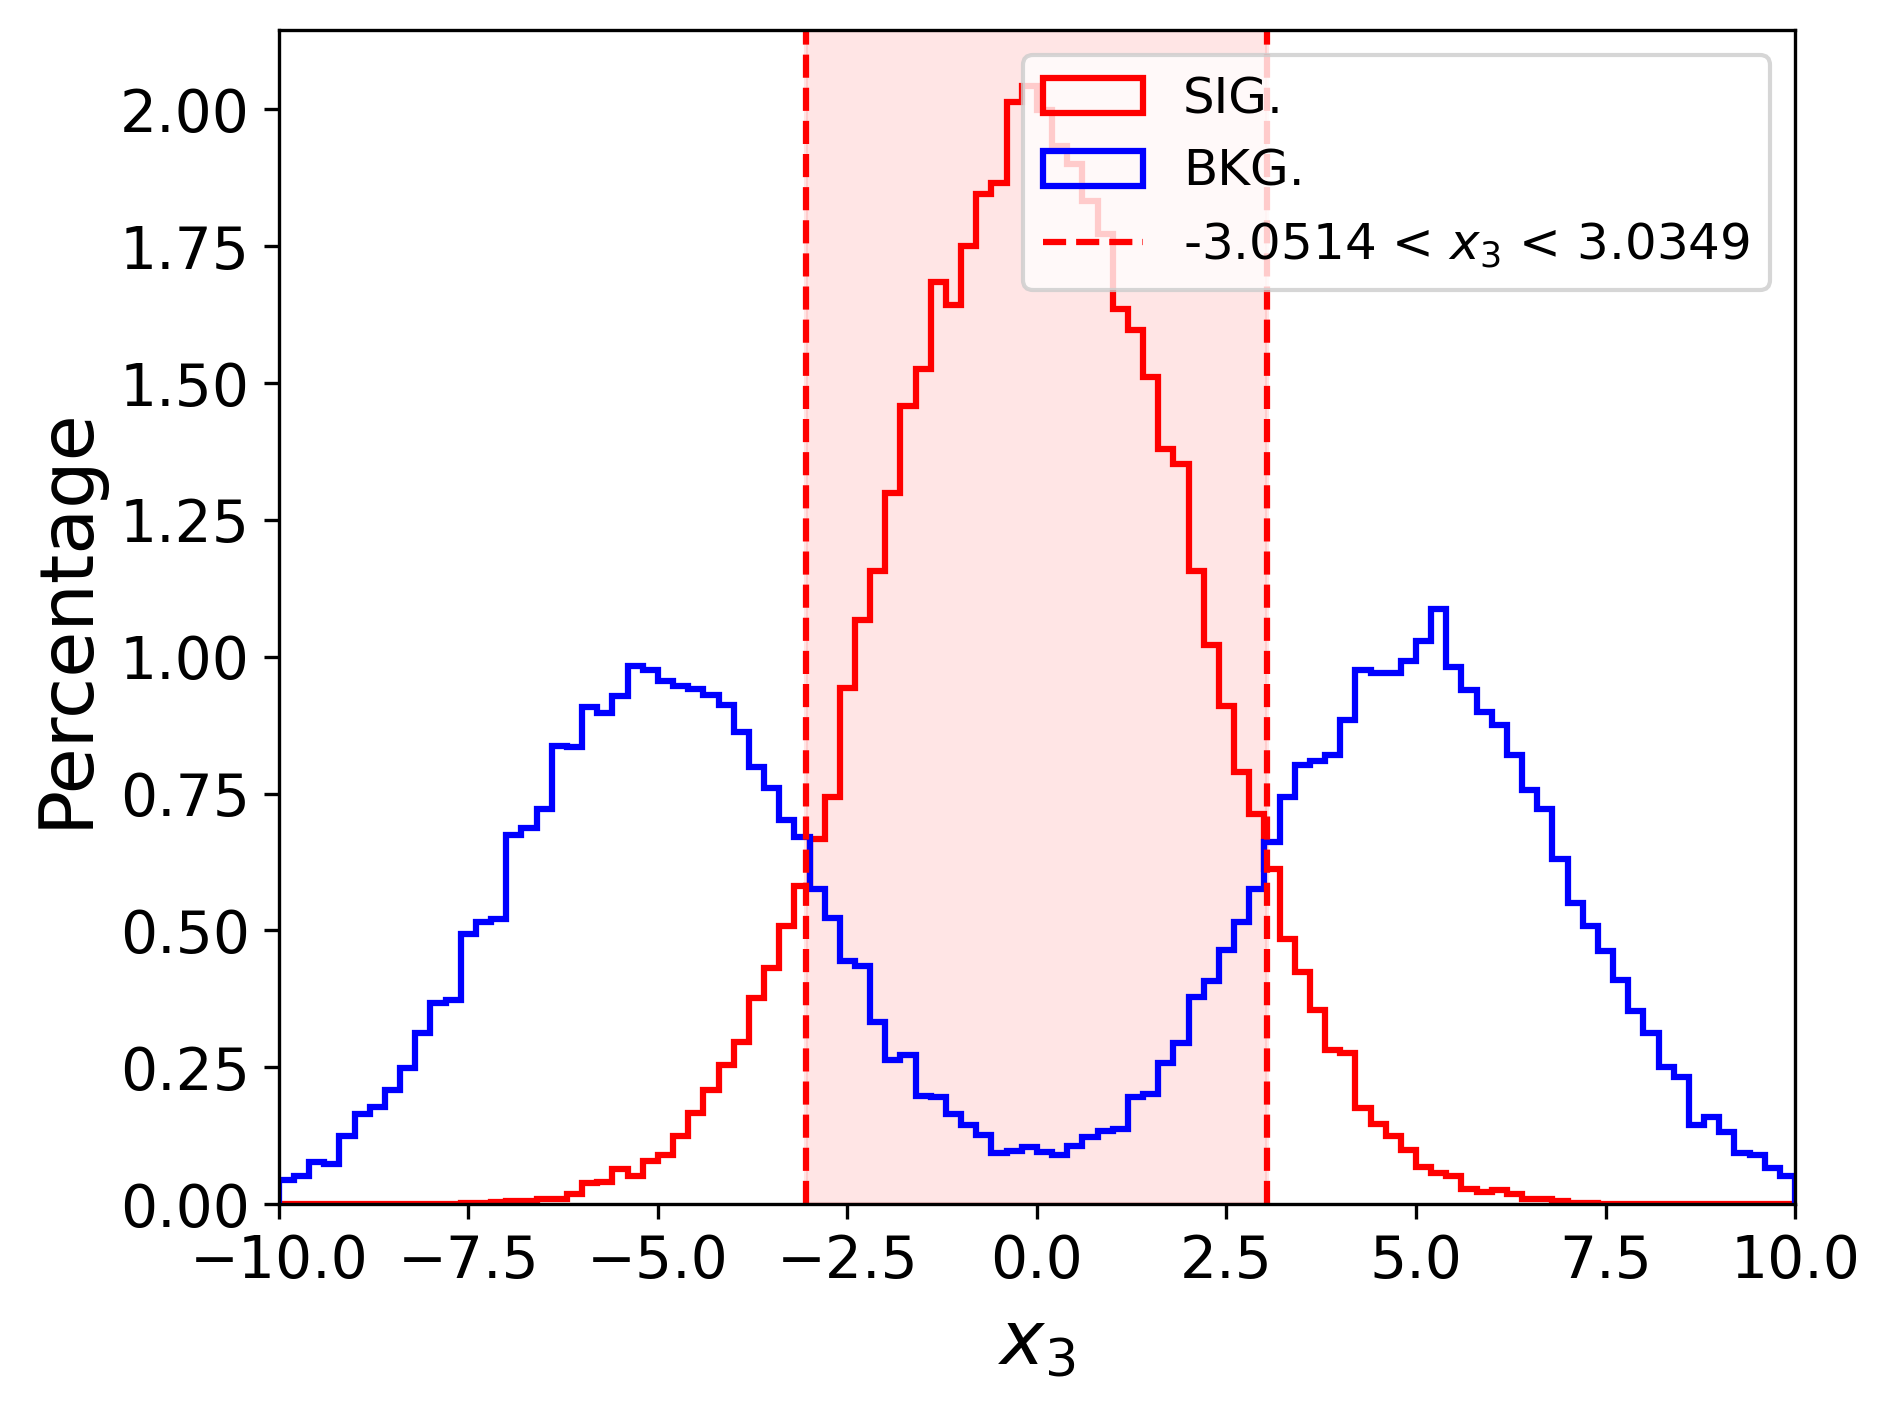

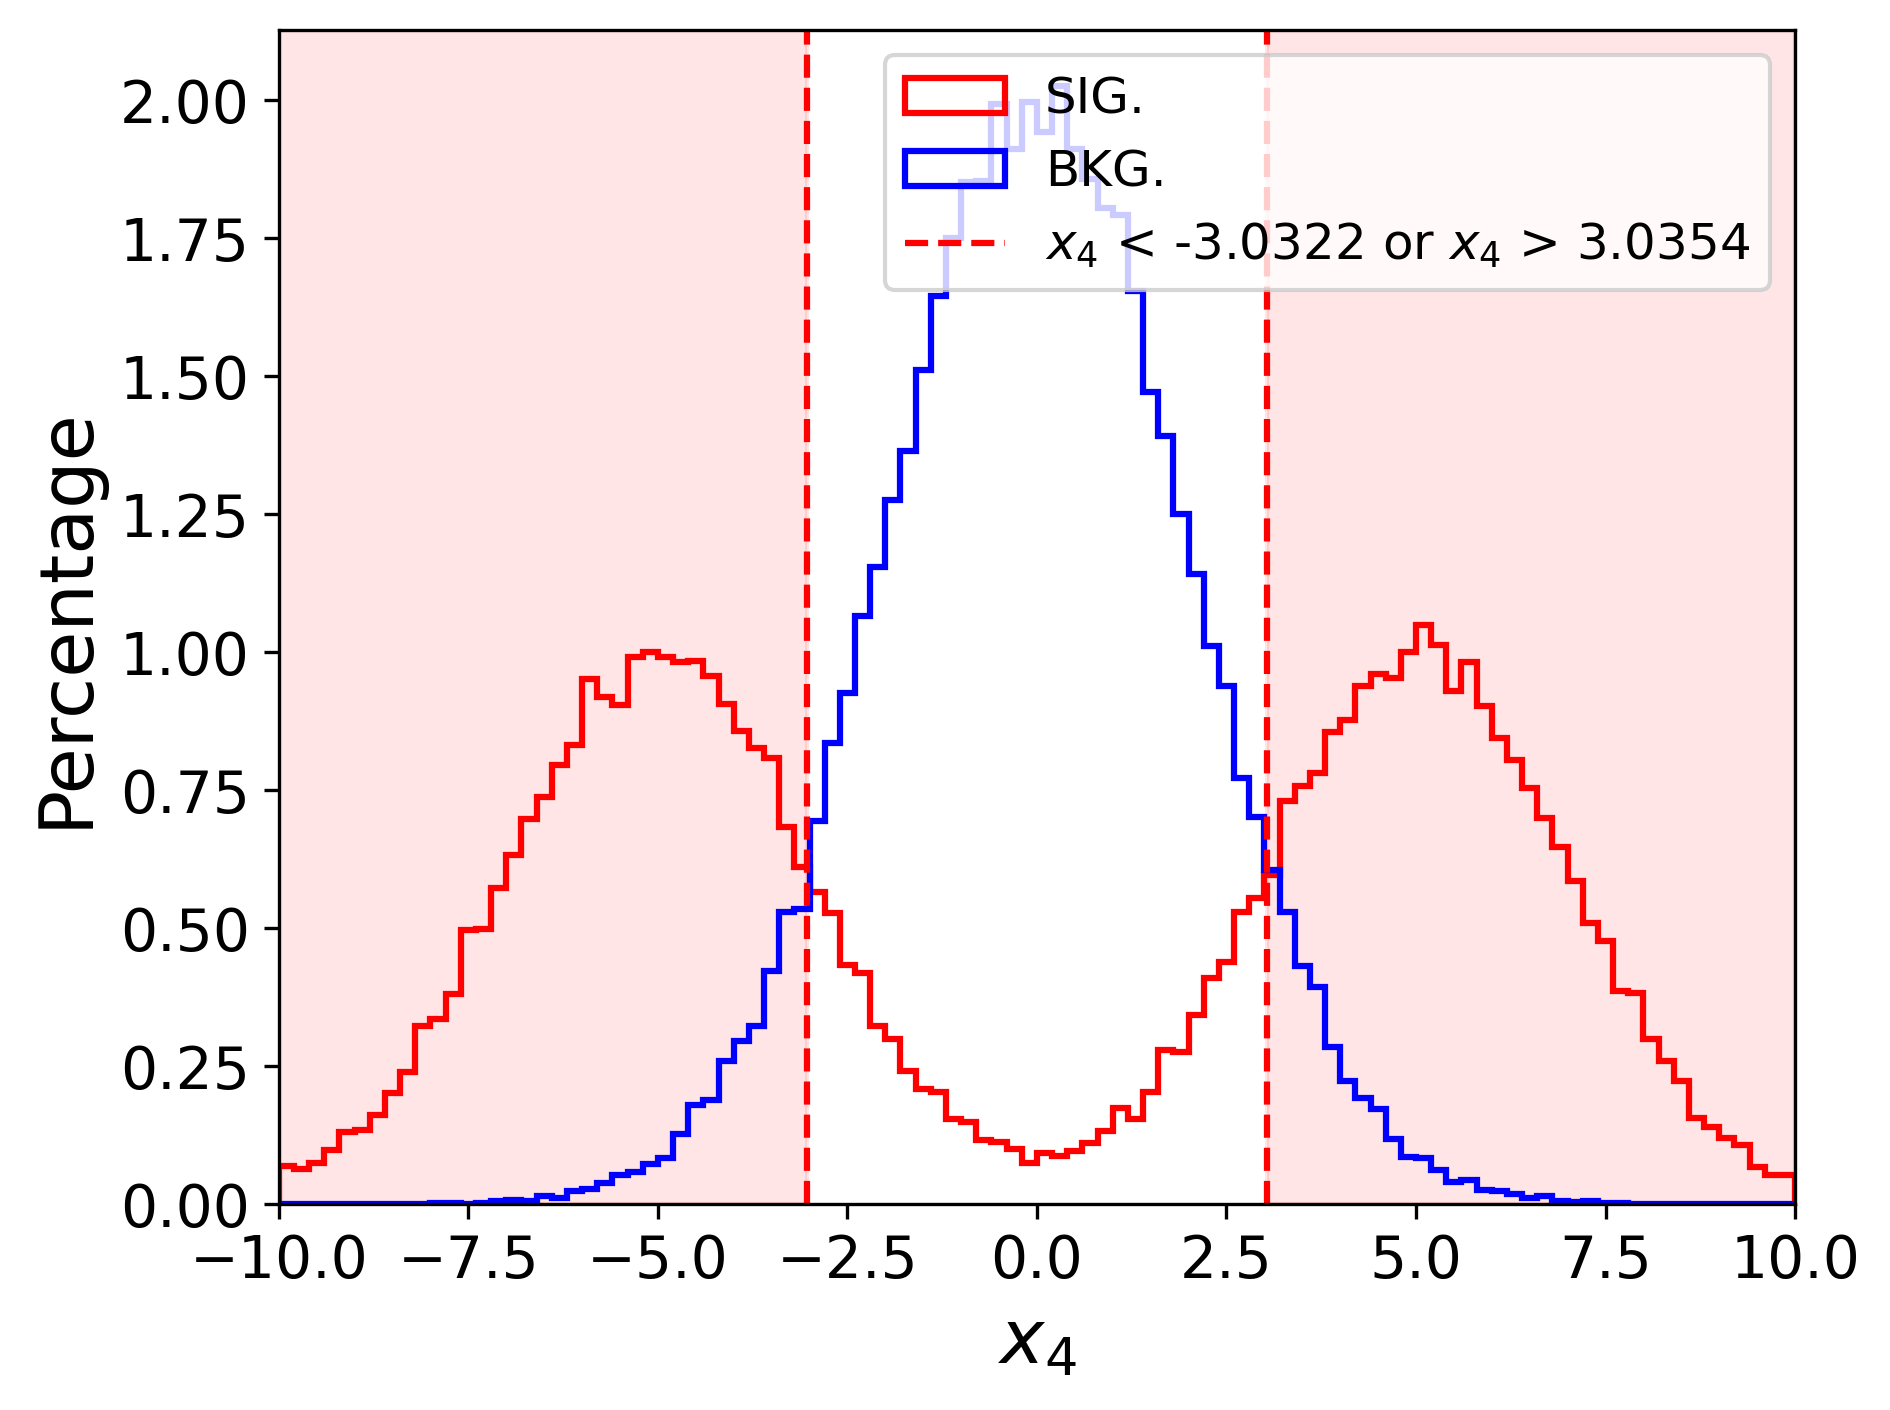

In [10]:
# Figure: learned cuts
features_str = [tex_to_str(feature) for feature in features]

df = pd.DataFrame(x_test, columns=features_str)
df["y"] = y_test.squeeze()

for i, feature in enumerate(features):
    sig = df.query("y == 1")[features_str[i]]
    bkg = df.query("y == 0")[features_str[i]]
    weights_sig = 100 * np.ones_like(sig) / len(df)
    weights_bkg = 100 * np.ones_like(bkg) / len(df)

    plot_learned_cut(
        case=cut_cases[i],
        index=cut_indices[i],
        boundaries=cut_boundaries[i],
        expression=cut_expressions[i],
        data=[sig, bkg],
        bins=bins,
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
    )
    plot_learned_cut(
        case=cut_cases[i],
        index=cut_indices[i],
        boundaries=cut_boundaries[i],
        expression=cut_expressions[i],
        data=[sig, bkg],
        bins=bins,
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
        to_file=FIGURES_DIR / f"learned_cut-{tex_to_str(feature)}(x10).pdf",
    )

    if isinstance(checkpoint, LearnableCutFlowSequentialModel):
        cut_query = checkpoint.cuts[i].expression.replace(
            features[i], f"`{features_str[i]}`"
        )
        df = df.query(cut_query)

In [11]:
# Analysis: learned importance (x10)
importance_score_means = []
importance_score_stds = []

for i in range(x_test.shape[1]):
    for checkpoint in checkpoints:
        assert checkpoint.cuts[i].case == checkpoints[0].cuts[i].case
        assert checkpoint.cuts[i].index == checkpoints[0].cuts[i].index

importance_scores = []
for checkpoint in checkpoints:
    importance_scores.append(checkpoint.importance.scores)

importance_scores_mean = ops.mean(importance_scores, axis=0)
importance_scores_std = ops.std(importance_scores, axis=0)

for i in range(x_test.shape[1]):
    print(f"{importance_scores_mean[i]:.4f} ± {importance_scores_std[i]:.4f}")

0.1886 ± 0.0098
0.1783 ± 0.0075
0.3173 ± 0.0079
0.3158 ± 0.0060


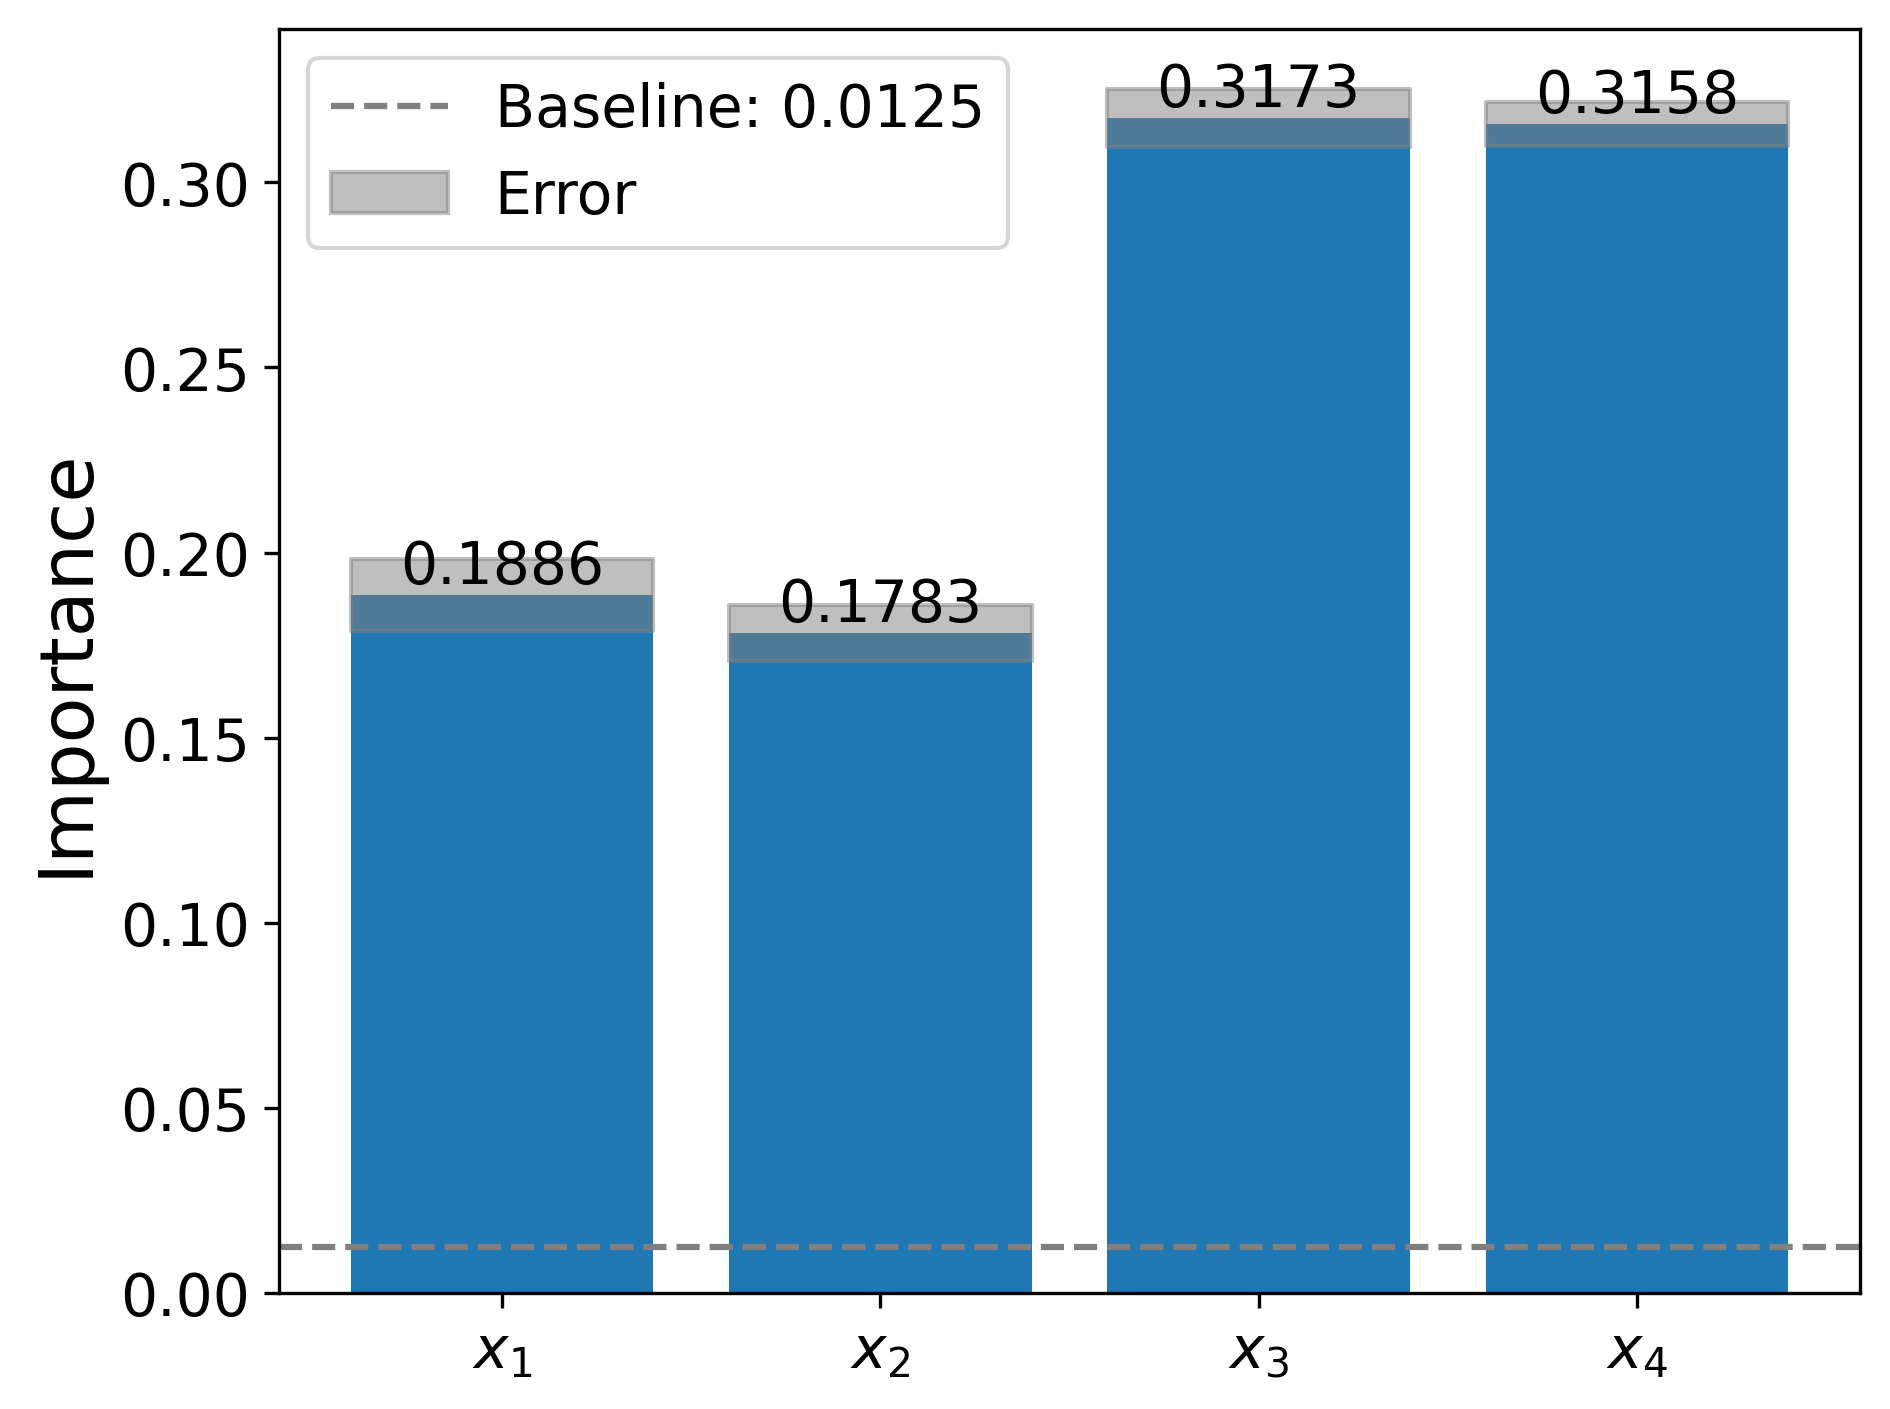

In [12]:
# Figure: learned importance (x10)
plot_learned_importance(
    scores=importance_scores_mean,
    errors=importance_scores_std,
    baseline=checkpoint.importance.baseline,
    features=features,
)
plot_learned_importance(
    scores=importance_scores_mean,
    errors=importance_scores_std,
    baseline=checkpoint.importance.baseline,
    features=features,
    to_file=FIGURES_DIR / "learned_importance(x10).pdf",
)